<a href="https://colab.research.google.com/github/Ganeshreddyv123/Advanced-Computer-Science-Masters-Project/blob/main/Ganesh_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing Required Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Loading the Dataset

In [ ]:
heart_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/heart_dataset.csv')

## Data Preprocessing

In [ ]:
heart_data.head()

,Age,Sex,Chest Pain,Blood Pressure,Cholesterol,FBS over 120,EKG Results,Maximum HR,Exercise Angina,ST Depression,ST Slope,Number of Fluro Vessels,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
heart_data.isnull().sum()

,0
Age,0
Sex,0
Chest Pain,0
Blood Pressure,0
Cholesterol,0
FBS over 120,0
EKG Results,0
Maximum HR,0
Exercise Angina,0
ST Depression,0


In [ ]:
heart_data.duplicated().sum()

np.int64(0)

In [ ]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest Pain               270 non-null    int64  
 3   Blood Pressure           270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG Results              270 non-null    int64  
 7   Maximum HR               270 non-null    int64  
 8   Exercise Angina          270 non-null    int64  
 9   ST Depression            270 non-null    float64
 10  ST Slope                 270 non-null    int64  
 11  Number of Fluro Vessels  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
ctg_list = ["Sex", "Chest Pain","FBS over 120","EKG Results","Exercise Angina","ST Slope", "Thallium", "Number of Fluro Vessels","Heart Disease"]

## Exploratory Data Analysis (EDA)

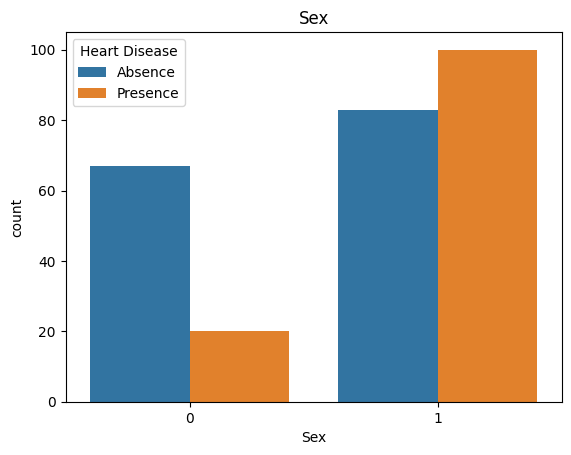

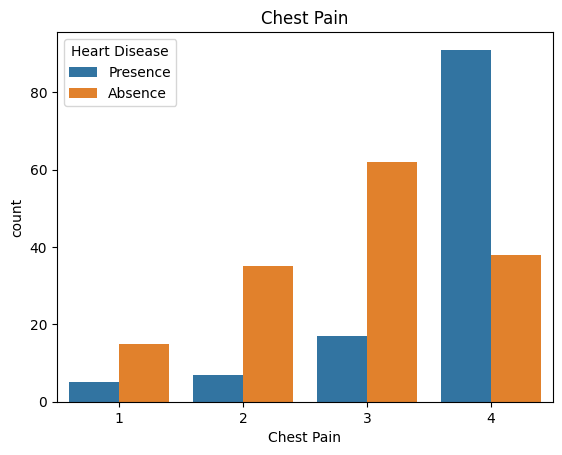

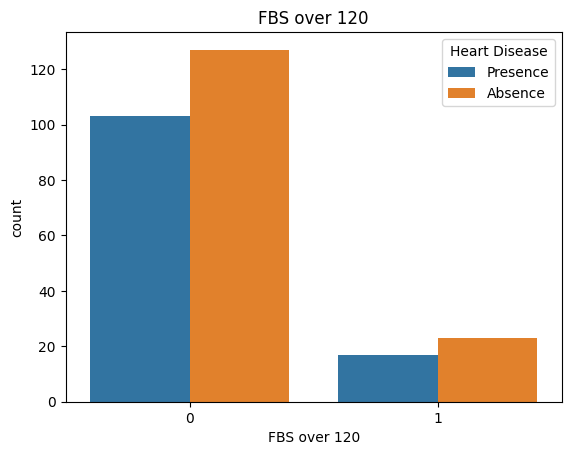

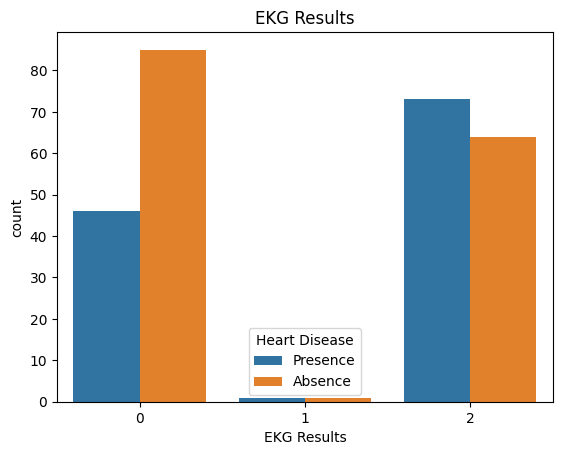

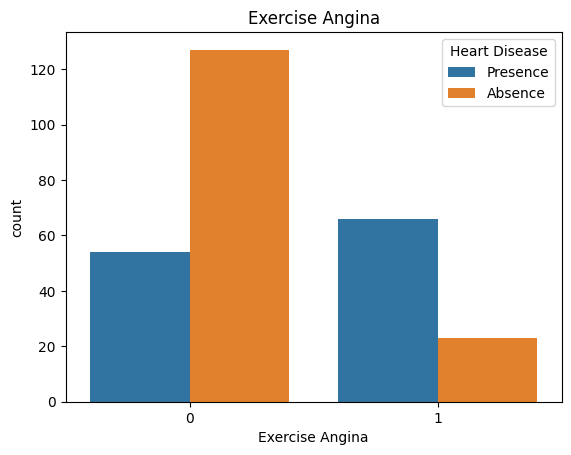

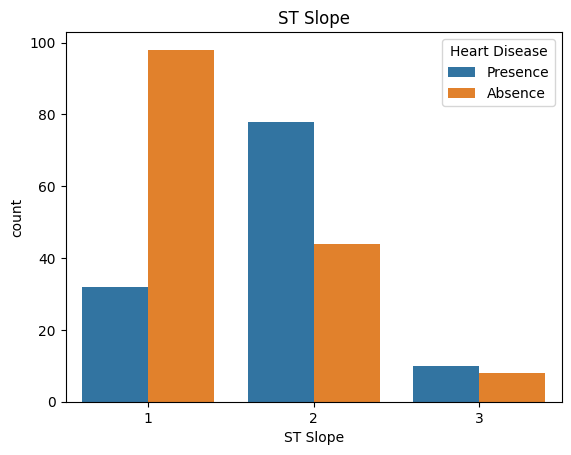

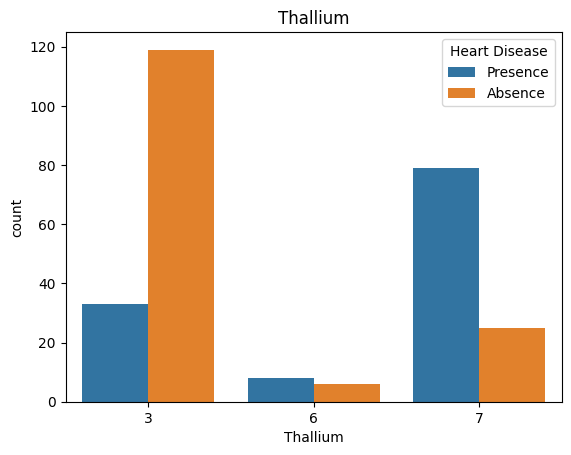

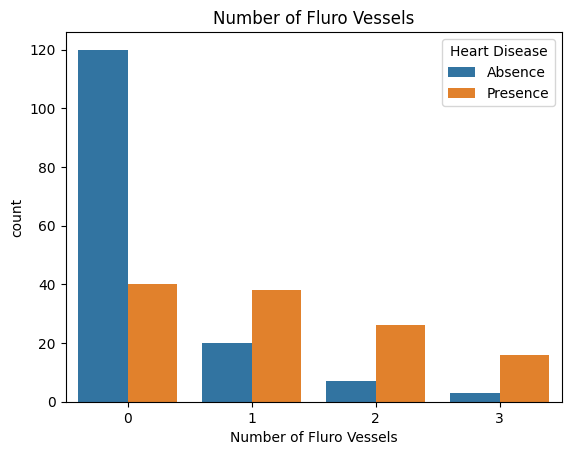

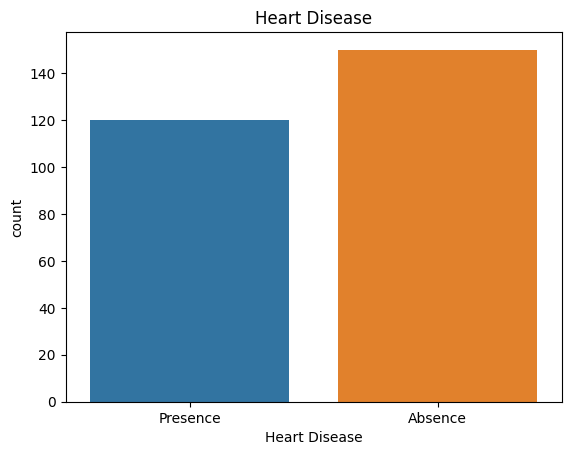

In [ ]:
df_ctg = heart_data.loc[:, ctg_list]
for i in ctg_list:
    plt.figure()
    sns.countplot(x = i, data = df_ctg, hue = "Heart Disease")
    plt.title(i)

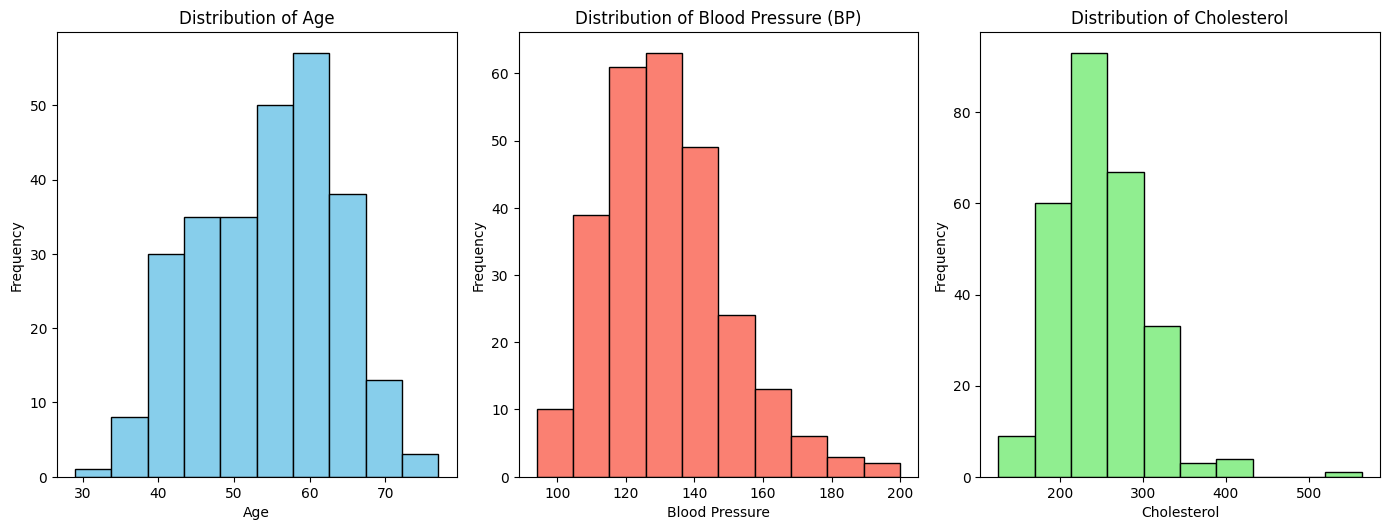

In [ ]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.hist(heart_data['Age'], bins=10, edgecolor='k', color='skyblue')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")


plt.subplot(2, 3, 2)
plt.hist(heart_data['Blood Pressure'], bins=10, edgecolor='k', color='salmon')
plt.title("Distribution of Blood Pressure (BP)")
plt.xlabel("Blood Pressure")
plt.ylabel("Frequency")


plt.subplot(2, 3, 3)
plt.hist(heart_data['Cholesterol'], bins=10, edgecolor='k', color='lightgreen')
plt.title("Distribution of Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

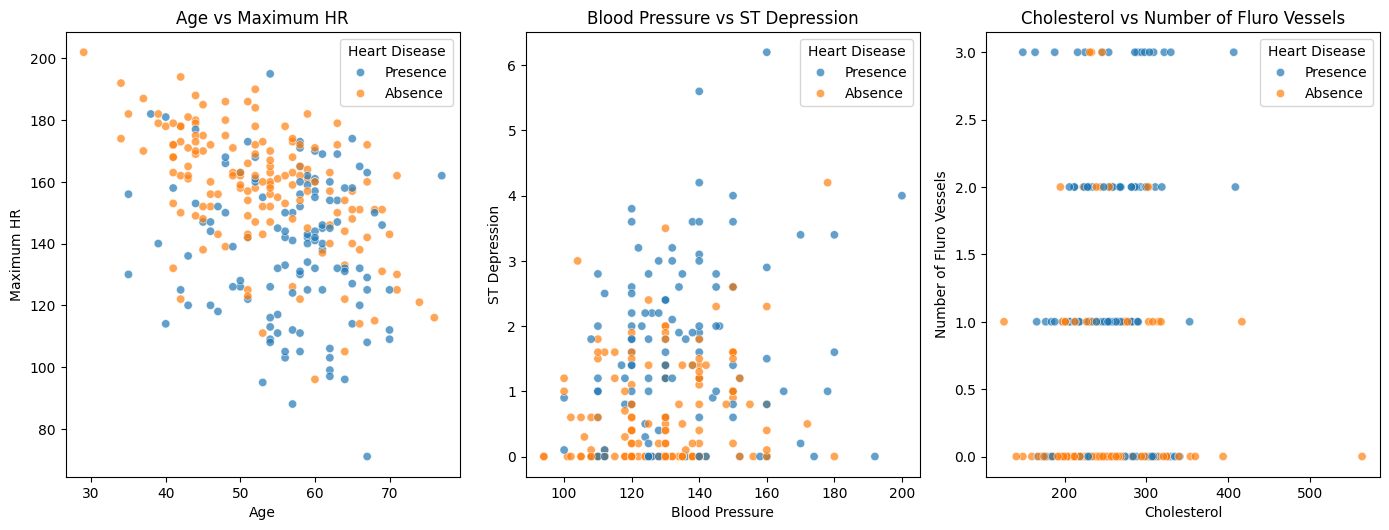

In [ ]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
sns.scatterplot(x = 'Age', y = 'Maximum HR', hue = "Heart Disease", data = heart_data, alpha=0.7, color='purple')
plt.title("Age vs Maximum HR")
plt.xlabel("Age")
plt.ylabel("Maximum HR")


plt.subplot(2, 3, 2)
sns.scatterplot(x = 'Blood Pressure', y  = 'ST Depression', data = heart_data,hue = "Heart Disease", alpha=0.7, color='orange')
plt.title("Blood Pressure vs ST Depression")
plt.xlabel("Blood Pressure")
plt.ylabel("ST Depression")

plt.subplot(2, 3, 3)
sns.scatterplot(x = 'Cholesterol', y = 'Number of Fluro Vessels', data = heart_data,hue = "Heart Disease", alpha=0.7, color='teal')
plt.title("Cholesterol vs Number of Fluro Vessels")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Fluro Vessels")


plt.tight_layout()
plt.show()

In [ ]:
temp = heart_data.drop(columns = ctg_list)

In [ ]:
temp.head()

,Age,Blood Pressure,Cholesterol,Maximum HR,ST Depression
0,70,130,322,109,2.4
1,67,115,564,160,1.6
2,57,124,261,141,0.3
3,64,128,263,105,0.2
4,74,120,269,121,0.2


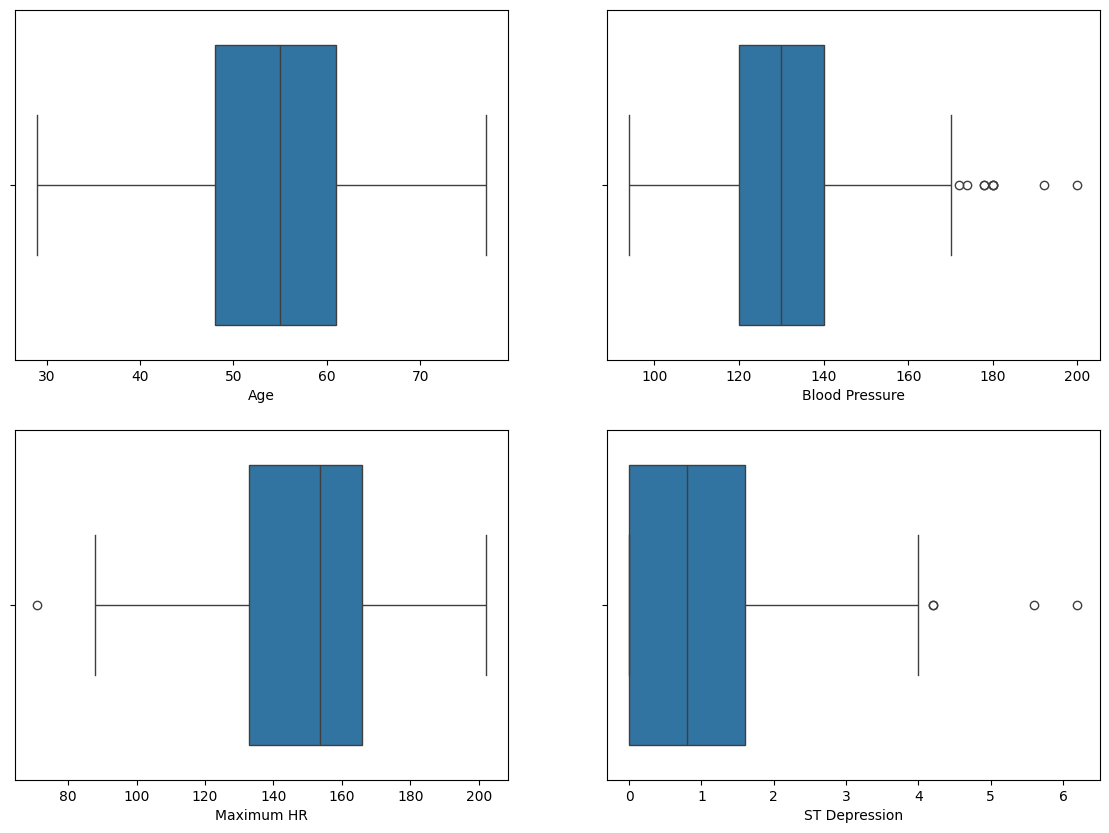

In [ ]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data = temp, x='Age')

plt.subplot(2, 2, 2)
sns.boxplot(data = temp, x='Blood Pressure')

plt.subplot(2, 2, 3)
sns.boxplot(data = temp, x='Maximum HR')

plt.subplot(2, 2, 4)
sns.boxplot(data = temp, x='ST Depression')

plt.show()

## **Model Building & Evaluation**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from sklearn.preprocessing import StandardScaler

### **Pre-Processing & Train-Test Split**

In [ ]:
lbl_encoder = LabelEncoder()

In [ ]:
heart_data['Heart Disease'] = lbl_encoder.fit_transform(heart_data['Heart Disease'])

In [ ]:
number_column = ['Age', 'Blood Pressure', 'Cholesterol', 'Maximum HR', 'ST Depression']

In [ ]:
standsc = StandardScaler()
heart_data[number_column] = standsc.fit_transform(heart_data[number_column])

In [ ]:
x = heart_data.drop(columns=['Heart Disease'],axis = 1)
y = heart_data['Heart Disease']

In [ ]:
x.head()

,Age,Sex,Chest Pain,Blood Pressure,Cholesterol,FBS over 120,EKG Results,Maximum HR,Exercise Angina,ST Depression,ST Slope,Number of Fluro Vessels,Thallium
0,1.712094,1,4,-0.075410,1.402212,0,2,-1.759208,0,1.181012,2,3,3
1,1.382140,0,3,-0.916759,6.093004,0,2,0.446409,0,0.481153,2,0,7
2,0.282294,1,2,-0.411950,0.219823,0,0,-0.375291,0,-0.656118,1,0,7
3,1.052186,1,4,-0.187590,0.258589,0,0,-1.932198,1,-0.743600,2,1,7
4,2.152032,0,2,-0.636310,0.374890,0,2,-1.240239,1,-0.743600,1,1,3


In [ ]:
y.head()

,Heart Disease
0,1
1,0
2,1
3,0
4,0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape

(216, 13)

In [ ]:
x_test.shape

(54, 13)

### **Model Sampling & Hyperparameter Tuning**

In [ ]:
!pip install imbalanced-learn -q

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

In [ ]:
def evaluate_model(model, x_train_data, y_train_data, x_test_data, y_test_data, model_name, sampling_type):
    model.fit(x_train_data, y_train_data)
    y_pred = model.predict(x_test_data)

    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    print("\n========================================")
    print(f"{model_name} - {sampling_type}")
    print("========================================")
    print("Accuracy:", round(accuracy, 2))
    print(classification_report(y_test_data, y_pred))

    return {
        "Model": model_name,
        "Sampling Technique": sampling_type,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Predictions": y_pred
    }


#Defining Models

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}


results = []


#Class Imbalance Data

for model_name, model in models.items():
    result = evaluate_model(
        model,
        x_train,
        y_train,
        x_test,
        y_test,
        model_name,
        "Class Imbalanced"
    )
    results.append(result)


# Undersampling

under_sampler = RandomUnderSampler(random_state=42)
x_train_under, y_train_under = under_sampler.fit_resample(x_train, y_train)

print("\nClass distribution after undersampling:")
print(pd.Series(y_train_under).value_counts())

for model_name, model in models.items():
    result = evaluate_model(
        model,
        x_train_under,
        y_train_under,
        x_test,
        y_test,
        model_name,
        "Under Sampling"
    )
    results.append(result)



# Oversampling


over_sampler = RandomOverSampler(random_state=42)
x_train_over, y_train_over = over_sampler.fit_resample(x_train, y_train)

print("\nClass distribution after oversampling:")
print(pd.Series(y_train_over).value_counts())

for model_name, model in models.items():
    result = evaluate_model(
        model,
        x_train_over,
        y_train_over,
        x_test,
        y_test,
        model_name,
        "Over Sampling"
    )
    results.append(result)

# Hyperparameter tuning

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(x_train_over, y_train_over)

best_logistic_model = grid_search.best_estimator_

print("\nBest parameters for Logistic Regression:")
print(grid_search.best_params_)

tuned_result = evaluate_model(
    best_logistic_model,
    x_train_over,
    y_train_over,
    x_test,
    y_test,
    "Tuned Logistic Regression",
    "Over Sampling"
)

results.append(tuned_result)

# Create final results table

results_df = pd.DataFrame(results)

# Remove predictions column for display
results_table = results_df.drop(columns=["Predictions"])

print("\nFinal Model Comparison Table:")
display(results_table)



Random Forest - Class Imbalanced
Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        33
           1       0.78      0.67      0.72        21

    accuracy                           0.80        54
   macro avg       0.79      0.77      0.78        54
weighted avg       0.79      0.80      0.79        54


Logistic Regression - Class Imbalanced
Accuracy: 0.91
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54


XGBoost - Class Imbalanced
Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.83      0.88      0.85        33
           1       0.79      0.71      0.75        21

    accuracy                        

,Model,Sampling Technique,Accuracy,Precision,Recall,F1-Score
0,Random Forest,Class Imbalanced,0.796296,0.777778,0.666667,0.717949
1,Logistic Regression,Class Imbalanced,0.907407,0.900000,0.857143,0.878049
2,XGBoost,Class Imbalanced,0.814815,0.789474,0.714286,0.750000
3,Random Forest,Under Sampling,0.833333,0.772727,0.809524,0.790698
4,Logistic Regression,Under Sampling,0.907407,0.944444,0.809524,0.871795
5,XGBoost,Under Sampling,0.833333,0.800000,0.761905,0.780488
6,Random Forest,Over Sampling,0.814815,0.761905,0.761905,0.761905
7,Logistic Regression,Over Sampling,0.888889,0.857143,0.857143,0.857143
8,XGBoost,Over Sampling,0.833333,0.800000,0.761905,0.780488
9,Tuned Logistic Regression,Over Sampling,0.814815,0.823529,0.666667,0.736842


### **Model Comparison Bar Chart**

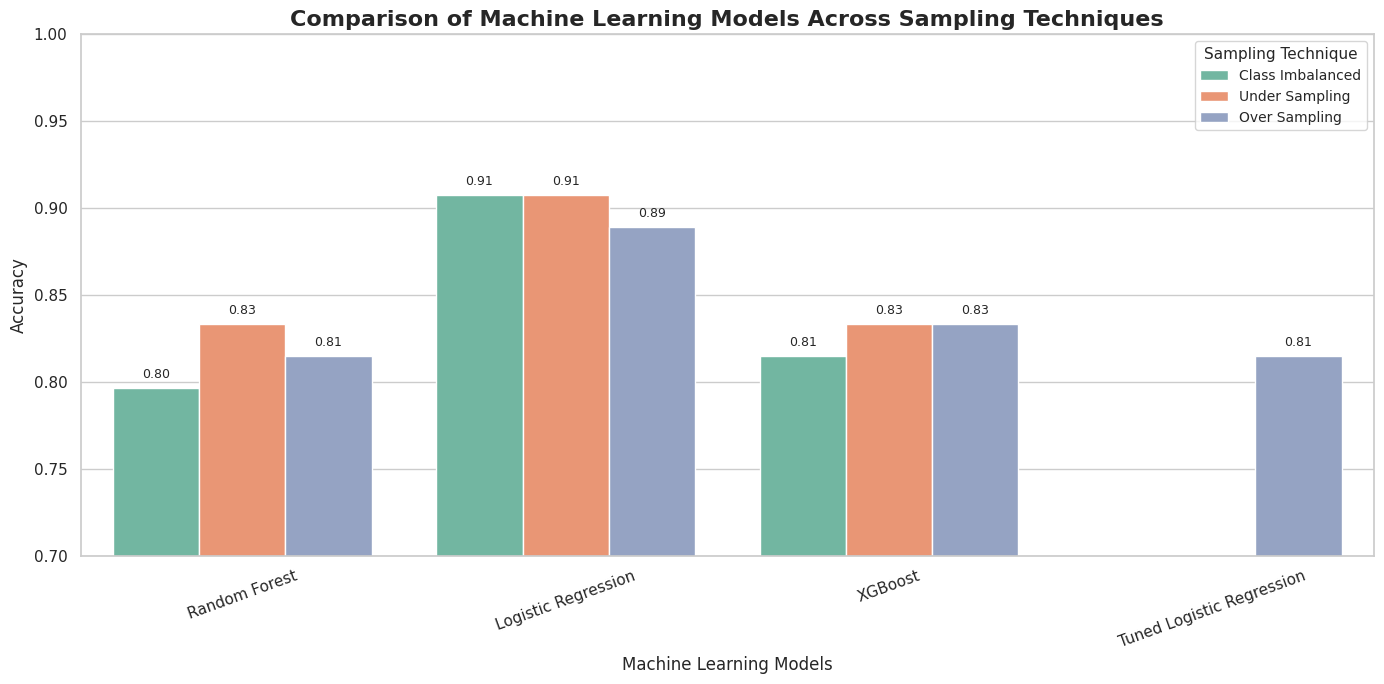

In [ ]:
# Bar Chart
sns.set(style="whitegrid")

plt.figure(figsize=(14, 7))

# Create bar chart
barplot = sns.barplot(
    data=results_table,
    x="Model",
    y="Accuracy",
    hue="Sampling Technique",
    palette="Set2"
)

# Add title and labels
plt.title("Comparison of Machine Learning Models Across Sampling Techniques", fontsize=16, weight='bold')
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

# Rotate x labels slightly
plt.xticks(rotation=20)

# Set y-axis limit
plt.ylim(0.7, 1.0)

# Add value labels on bars
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{height:.2f}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     fontsize=9,
                     xytext=(0, 5),
                     textcoords='offset points')

# Legend formatting
plt.legend(title="Sampling Technique", title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()

### **Random Forest : Model & Prediction**


In [ ]:
rf = RandomForestClassifier()

In [ ]:
rf.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
prediction_rf = rf.predict(x_test)

In [ ]:
accuracy_score(y_test, prediction_rf)

0.8703703703703703

In [ ]:
print(classification_report(y_test, prediction_rf))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90        33
           1       0.89      0.76      0.82        21

    accuracy                           0.87        54
   macro avg       0.88      0.85      0.86        54
weighted avg       0.87      0.87      0.87        54



In [ ]:
conf_m = confusion_matrix(y_test, prediction_rf)

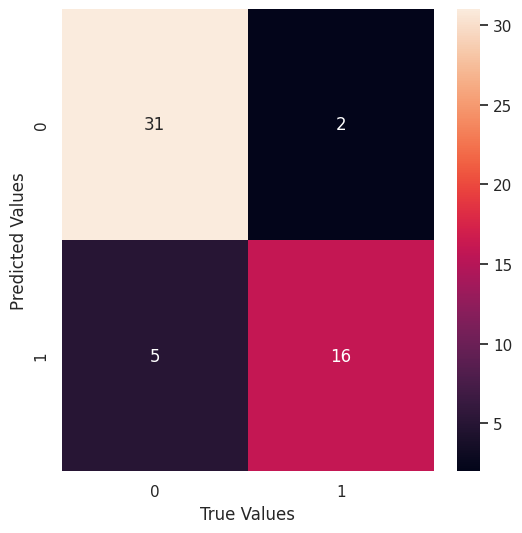

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(conf_m, annot=True)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.show()

### **Logistic Regression : Model & Prediction**


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_reg = LogisticRegression(random_state=0)
log_reg.fit(x_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
prediction_lg = log_reg.predict(x_test)

In [ ]:
accuracy_score(y_test, prediction_lg)

0.9074074074074074

In [ ]:
print(classification_report(y_test, prediction_lg))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



In [ ]:
conf_m = confusion_matrix(y_test, prediction_lg)

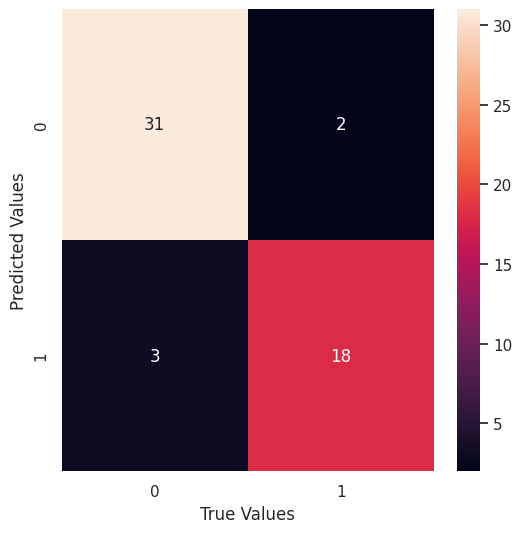

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(conf_m, annot=True)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.show()

### **XG Boost : Model & Prediction**

In [ ]:
from xgboost import XGBClassifier

In [ ]:
XGBoost = XGBClassifier()
XGBoost.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
prediction_XG = XGBoost.predict(x_test)

In [ ]:
accuracy_score(y_test, prediction_XG)

0.8148148148148148

In [ ]:
print(classification_report(y_test, prediction_XG))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85        33
           1       0.79      0.71      0.75        21

    accuracy                           0.81        54
   macro avg       0.81      0.80      0.80        54
weighted avg       0.81      0.81      0.81        54



In [ ]:
conf_m = confusion_matrix(y_test, prediction_XG)

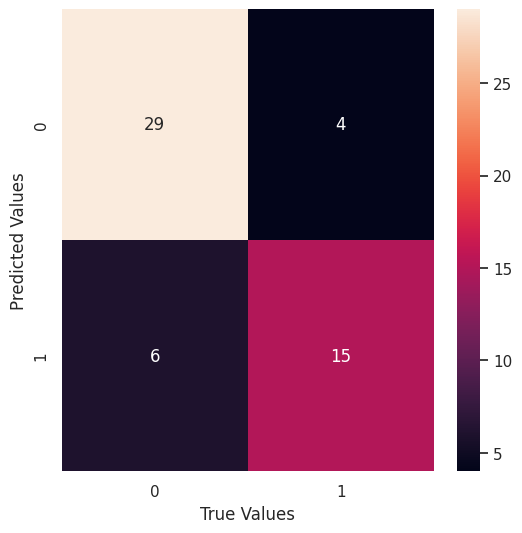

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(conf_m, annot=True)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.show()

###**Model Comparison Table**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
models = {
    "Random Forest": prediction_rf,
    "Logistic Regression": prediction_lg,
    "XGBoost": prediction_XG
}

results = []

for name, preds in models.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("Model Comparison Table:")
print(results_df)

Model Comparison Table:
                 Model  Accuracy  Precision    Recall  F1 Score
1  Logistic Regression  0.907407   0.900000  0.857143  0.878049
0        Random Forest  0.870370   0.888889  0.761905  0.820513
2              XGBoost  0.814815   0.789474  0.714286  0.750000


###**Confusion Matrices**

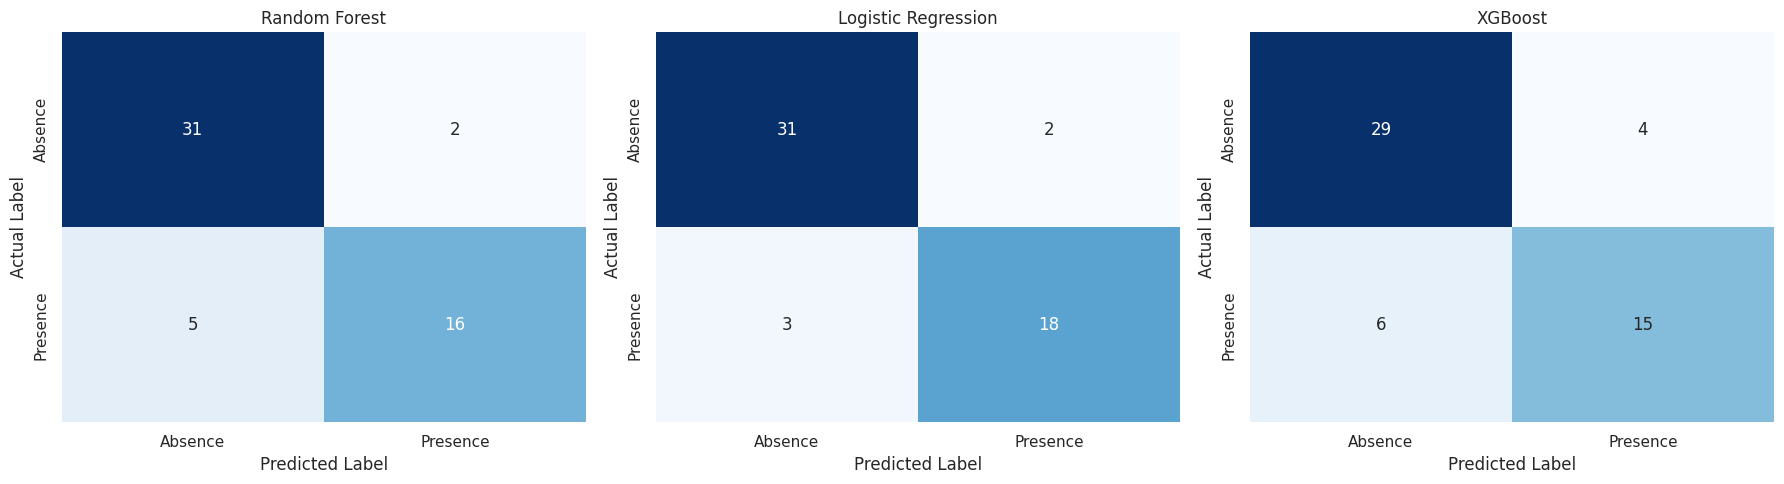

In [ ]:
models = {
    "Random Forest": prediction_rf,
    "Logistic Regression": prediction_lg,
    "XGBoost": prediction_XG
}

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Absence','Presence'],
        yticklabels=['Absence','Presence'],
        cbar=False,
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

###**ROC Curve**

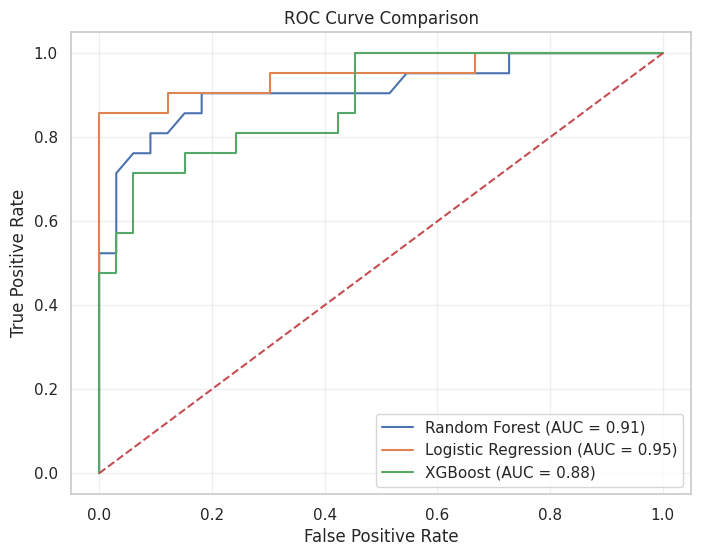

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
models = {
    "Random Forest": rf,
    "Logistic Regression": log_reg,
    "XGBoost": XGBoost
}

for name, model in models.items():

    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_test)[:, 1]
    else:
        y_score = model.decision_function(x_test)

    # ROC calculation
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

###**Feature Importance**

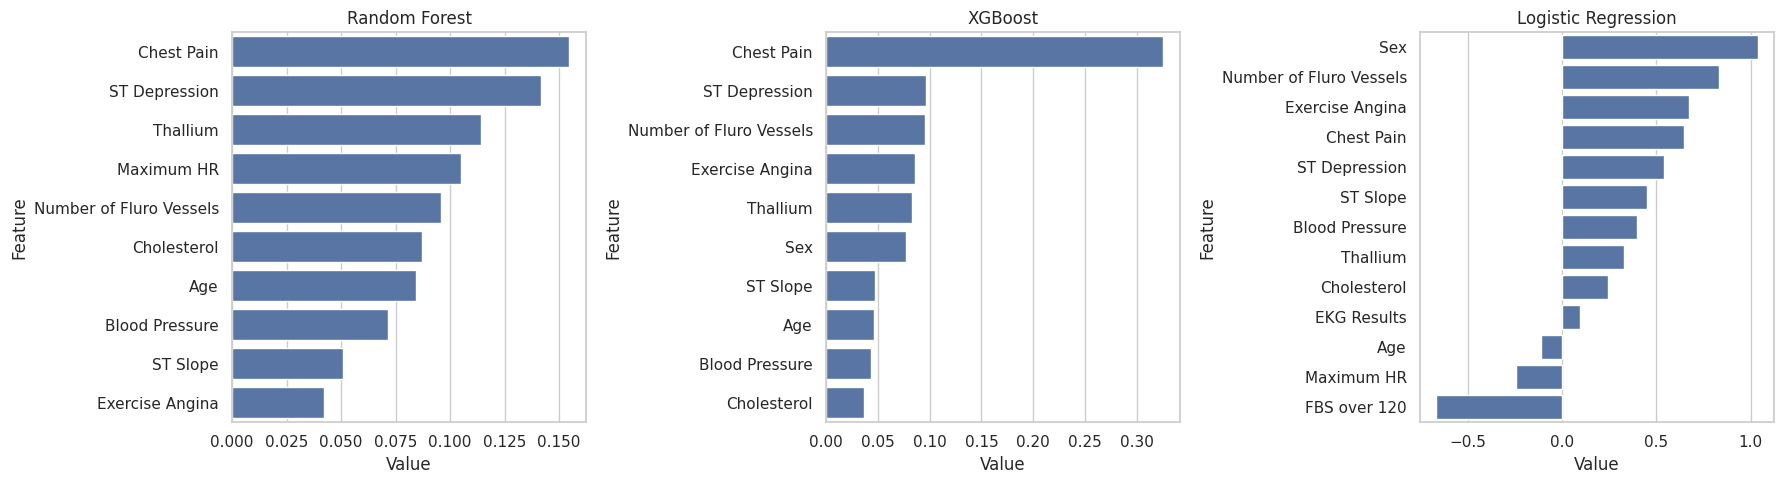

In [ ]:
feature_names = x_train.columns

# Create DataFrames
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Value": rf.feature_importances_
}).sort_values(by="Value", ascending=False)

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Value": XGBoost.feature_importances_
}).sort_values(by="Value", ascending=False)

lr_coef = pd.DataFrame({
    "Feature": feature_names,
    "Value": log_reg.coef_[0]
}).sort_values(by="Value", ascending=False)

# Create subplots (side-by-side)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest
sns.barplot(data=rf_importance.head(10), x="Value", y="Feature", ax=axes[0])
axes[0].set_title("Random Forest")

# XGBoost
sns.barplot(data=xgb_importance.head(10), x="Value", y="Feature", ax=axes[1])
axes[1].set_title("XGBoost")

# Logistic Regression
sns.barplot(data=lr_coef, x="Value", y="Feature", ax=axes[2])
axes[2].set_title("Logistic Regression")

plt.tight_layout()
plt.show()